# Análisis de Noticias BBC
### Práctica 4: Clasificación y Modelado de Temas

**Autor:** Gabriel Gómez García

---

## Setup: Configuración del Entorno

Antes de nada, hay que montar el entorno de trabajo. Aquí dejo los pasos que he seguido en python 3.12:

### Pasos para configurar el entorno

**1. Crear y activar el entorno virtual:**

```bash
# Crear el entorno
python -m venv .venv

# Activarlo (en Windows)
.venv\Scripts\activate

```

**2. Instalar todas las librerías:**

He creado un archivo `requirements.txt` con todas las dependencias necesarias para este proyecto.

```bash
pip install -r requirements.txt

# Descargar el modelo de inglés para spaCy
python -m spacy download en_core_web_sm
```

---

## Bloque 0: Preparación del Entorno

Todas las librerías que voy a usar durante el análisis.

In [1]:
# Librerías de sistema
import os
import re
import math

# Librerías para manipulación de datos
import pandas as pd
import numpy as np

# Librerías de visualización
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from tqdm import tqdm

# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

# Librerías para procesamiento de texto
import spacy

# Librerías de ciencia de datos (sklearn)
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score

# Librerías de Gensim para modelado de temas
from gensim import corpora, models
from gensim.models import FastText, CoherenceModel

# Librerías para embeddings
from sentence_transformers import SentenceTransformer

# Para que siempre salga lo mismo
SEED = 42
np.random.seed(SEED)

---

## Bloque 1: Fase Exploratoria de Datos (EDA)

Lo primero es ver con qué estoy trabajando. Voy a cargar los datos y hacer un análisis básico para entender cómo son.

### Cargar los datos

In [2]:
# Ruta a la carpeta con los datos
data_path = 'bbc-train'

# Leer todos los archivos y organizarlos en un DataFrame
documentos = []
etiquetas = []

# Recorrer cada categoría (carpeta)
for categoria in os.listdir(data_path):
    categoria_path = os.path.join(data_path, categoria)
    
    # Verificar que sea una carpeta
    if os.path.isdir(categoria_path):
        # Leer cada archivo de texto en la carpeta
        for archivo in os.listdir(categoria_path):
            archivo_path = os.path.join(categoria_path, archivo)
            
            # Leer el contenido del archivo
            with open(archivo_path, 'r', encoding='utf-8', errors='ignore') as f:
                texto = f.read()
                documentos.append(texto)
                etiquetas.append(categoria)

# Crear el DataFrame
df = pd.DataFrame({
    'texto': documentos,
    'etiqueta': etiquetas
})

print(f"Total de documentos cargados: {len(df)}")
print(f"Categorías: {df['etiqueta'].unique()}")

Total de documentos cargados: 2015
Categorías: <StringArray>
['business', 'entertainment', 'politics', 'sports', 'tech']
Length: 5, dtype: str


### Primeras filas del dataset

In [3]:
df.head()

,texto,etiqueta
0,Ad sales boost Time Warner profit\n\nQuarterly...,business
1,Dollar gains on Greenspan speech\n\nThe dollar...,business
2,Yukos unit buyer faces loan claim\n\nThe owner...,business
3,High fuel prices hit BA's profits\n\nBritish A...,business
4,Pernod takeover talk lifts Domecq\n\nShares in...,business


### Información general

In [4]:
print("Información del DataFrame:")
print(f"Número de filas: {df.shape[0]}")
print(f"Número de columnas: {df.shape[1]}")
print("\nTipos de datos:")

Información del DataFrame:
Número de filas: 2015
Número de columnas: 2

Tipos de datos:


### Verificar si hay valores nulos

In [5]:
print("Valores nulos por columna:")
print(df.isnull().sum())
print("\nPorcentaje de valores nulos:")
print((df.isnull().sum() / len(df) * 100).round(2))

Valores nulos por columna:
texto       0
etiqueta    0
dtype: int64

Porcentaje de valores nulos:
texto       0.0
etiqueta    0.0
dtype: float64


### Distribución de las categorías

In [6]:
print("Conteo de documentos por categoría:")
conteo = df["etiqueta"].value_counts()
print(conteo)
print("\nPorcentajes:")
print((conteo / len(df) * 100).round(2))

Conteo de documentos por categoría:
etiqueta
sports           461
business         460
politics         377
tech             361
entertainment    356
Name: count, dtype: int64

Porcentajes:
etiqueta
sports           22.88
business         22.83
politics         18.71
tech             17.92
entertainment    17.67
Name: count, dtype: float64


### Gráfico de barras

Hago un gráfico para ver de forma visual cómo están distribuidas las categorías.

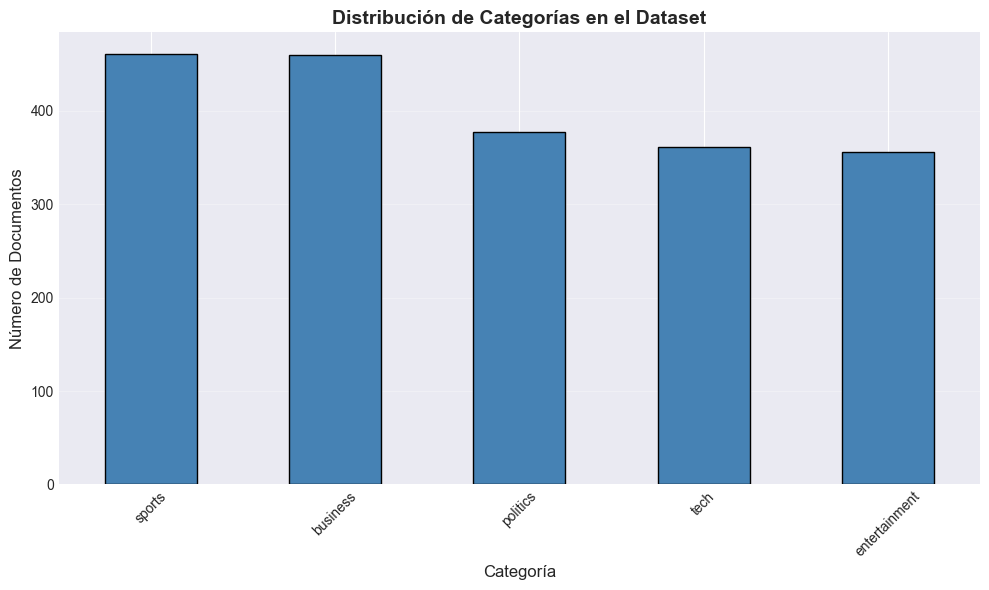

In [7]:
plt.figure(figsize=(10, 6))
df["etiqueta"].value_counts().plot(kind="bar", color="steelblue", edgecolor="black")
plt.title("Distribución de Categorías en el Dataset", fontsize=14, fontweight="bold")
plt.xlabel("Categoría", fontsize=12)
plt.ylabel("Número de Documentos", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### Longitud de los textos

Quiero ver cuántas palabras tienen los documentos de media y si hay mucha variación.

Estadísticas de longitud de textos (palabras):
count    2015.000000
mean      384.951861
std       233.618501
min       114.000000
25%       247.000000
50%       335.000000
75%       472.000000
max      4432.000000
Name: num_palabras, dtype: float64


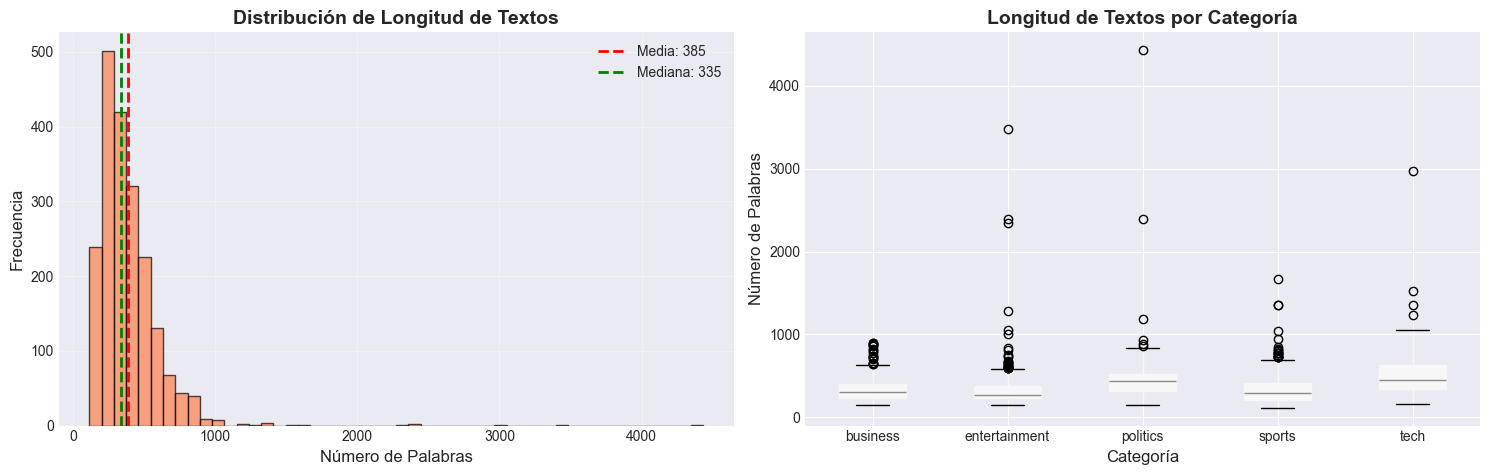


Longitud promedio por categoría:
                 mean     std  min   max
etiqueta                                
business       331.52  139.42  140   891
entertainment  336.44  270.80  145  3482
politics       447.06  272.09  142  4432
sports         331.78  183.35  114  1662
tech           503.92  245.21  162  2969


In [8]:
# Calcular número de palabras por documento
df["num_palabras"] = df["texto"].apply(lambda x: len(x.split()))

print("Estadísticas de longitud de textos (palabras):")
print(df["num_palabras"].describe())

# Visualizar distribución
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histograma
axes[0].hist(df["num_palabras"], bins=50, color="coral", edgecolor="black", alpha=0.7)
axes[0].axvline(
    df["num_palabras"].mean(),
    color="red",
    linestyle="--",
    linewidth=2,
    label=f'Media: {df["num_palabras"].mean():.0f}',
)
axes[0].axvline(
    df["num_palabras"].median(),
    color="green",
    linestyle="--",
    linewidth=2,
    label=f'Mediana: {df["num_palabras"].median():.0f}',
)
axes[0].set_title("Distribución de Longitud de Textos", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Número de Palabras", fontsize=12)
axes[0].set_ylabel("Frecuencia", fontsize=12)
axes[0].legend()
axes[0].grid(alpha=0.3)

# Boxplot por categoría
df.boxplot(column="num_palabras", by="etiqueta", ax=axes[1], patch_artist=True)
axes[1].set_title("Longitud de Textos por Categoría", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Categoría", fontsize=12)
axes[1].set_ylabel("Número de Palabras", fontsize=12)
plt.suptitle("")  # Quitar el título automático

plt.tight_layout()
plt.show()

# Estadísticas por categoría
print("\nLongitud promedio por categoría:")
print(df.groupby("etiqueta")["num_palabras"].agg(["mean", "std", "min", "max"]).round(2))

### Resultados de exploración

Después de mirar los datos, ya tengo una idea clara de lo que hay:

Las categorías están bastante balanceadas. Sports y Business son las que más documentos tienen (461 y 460 respectivamente, alrededor del 23% cada una), mientras que Entertainment es la más pequeña con 356 documentos (17.67%). La diferencia entre la mayor y la menor es de solo del 5%. Aunque hay un ligero desbalance, no es mucho.

Respecto a las palabras según categoría, la media está en 385 palabras por documento, pero la desviación estándar de 234 palabras indica que hay bastante dispersión. De hecho, el texto más corto tiene 114 palabras y el más largo 4432 palabras.

Mirando por categorías, veo patrones interesantes:
- Tech y Politics son las más largas (504 y 447 palabras de media). Tiene sentido porque suelen ser temas que requieren más explicación.
- Business, Sports y Entertainment rondan las 330 palabras, bastante similares entre sí.
- Entertainment y Politics tienen las desviaciones estándar más altas, lo que significa que dentro de esas categorías hay textos muy variados en longitud.

Esta diferencia en longitudes podría afectar a los modelos, sobre todo a los basados en frecuencia como TF-IDF. Los textos más largos naturalmente tendrán más palabras distintas, lo que podría darles más peso. Ya veremos si esto es un problema o si los modelos lo manejan bien.

Por último la calidad de los datos es muy buena. No hay valores nulos, así que no tengo que preocuparme por datos faltantes.

### División 60/20/20 (train/validación/test final)

Antes de limpiar nada, separo el dataset en tres partes:

- 60% para entrenamiento del modelo.
- 20% para validación durante el desarrollo.
- 20% como test final, reservado para el final de la práctica.

Esto evita fuga de información y mantiene una evaluación final limpia.

In [9]:
# 1) Primer split: 80% temporal y 20% test final
df_temporal_80, df_test_final_20 = train_test_split(
    df,
    test_size=0.20,
    random_state=42,
    stratify=df["etiqueta"],
 )

# 2) Segundo split dentro del 80%: 60% train y 20% validación
df_train_60, df_validacion_20 = train_test_split(
    df_temporal_80,
    test_size=0.25,  # 25% de 80% = 20% del total
    random_state=42,
    stratify=df_temporal_80["etiqueta"],
 )

print("Conjunto TRAIN (60%):")
print(f"  Total documentos: {len(df_train_60)}")
print(df_train_60["etiqueta"].value_counts().sort_index())

print("\nConjunto VALIDACIÓN (20%):")
print(f"  Total documentos: {len(df_validacion_20)}")
print(df_validacion_20["etiqueta"].value_counts().sort_index())

print("\nConjunto TEST FINAL (20%):")
print(f"  Total documentos: {len(df_test_final_20)}")
print(df_test_final_20["etiqueta"].value_counts().sort_index())

Conjunto TRAIN (60%):
  Total documentos: 1209
etiqueta
business         276
entertainment    214
politics         226
sports           277
tech             216
Name: count, dtype: int64

Conjunto VALIDACIÓN (20%):
  Total documentos: 403
etiqueta
business         92
entertainment    71
politics         75
sports           92
tech             73
Name: count, dtype: int64

Conjunto TEST FINAL (20%):
  Total documentos: 403
etiqueta
business         92
entertainment    71
politics         76
sports           92
tech             72
Name: count, dtype: int64


---

## Bloque 2: Preprocesamiento con spaCy

Los textos tal cual vienen del dataset tienen un montón de ruido: mayúsculas, puntuación, palabras que no aportan nada (como "the", "and", "is"...). Hay que limpiarlos para que los modelos puedan trabajar mejor.

### Cargar modelo de spaCy

In [10]:
# Cargar el modelo de inglés
nlp = spacy.load("en_core_web_sm")

# Desactivar componentes que no necesitamos para acelerar el procesamiento
# Solo necesitamos el tokenizador, lematizador y stop-words

# lo otro es parser para saber que es sujeto, objeto, verbo, etc.
# y ner para reconocer entidades nombradas como personas, lugares, organizaciones, etc.
# Pero no los necesitamos para esta tarea de análisis de noticias.
nlp.disable_pipes(["parser", "ner"])

print(f"Modelo cargado: {nlp.meta['name']}")
print(f"Idioma: {nlp.meta['lang']}")
print(f"Componentes activos: {nlp.pipe_names}")

Modelo cargado: core_web_sm
Idioma: en
Componentes activos: ['tok2vec', 'tagger', 'attribute_ruler', 'lemmatizer']


### Función de limpieza

Esta función va a hacer todo: convertir a minúsculas, quitar puntuación y números, lematizar (convertir las palabras a su forma base) y eliminar las stop-words.

In [11]:
def limpiar_texto(texto):
    """
    Limpia y preprocesa un texto usando spaCy.

    Pasos:
    1. Convertir a minúsculas
    2. Eliminar números y puntuación con regex
    3. Procesar con spaCy para lematizar
    4. Filtrar stop-words y tokens no alfabéticos

    Args:
        texto (str): Texto original a limpiar

    Returns:
        str: Texto limpio y lematizado
    """
    # 1. Convertir a minúsculas
    texto = texto.lower()

    # 2. Eliminar números y puntuación con regex
    texto = re.sub(r"\d+", "", texto)  # Quitar números
    texto = re.sub(r"[^\w\s]", " ", texto)  # Quitar puntuación
    texto = re.sub(r"\s+", " ", texto)  # Quitar espacios múltiples
    texto = texto.strip()

    # 3. Procesar con spaCy
    doc = nlp(texto)

    # 4. Lematizar y filtrar
    # Quitar stop-words
    # Quitar tokens que no sean alfabéticos
    # Quitar palabras de menos de 2 caracteres
    tokens_limpios = [
        token.lemma_
        for token in doc
        if not token.is_stop and token.is_alpha and len(token.lemma_) > 2
    ]

    return " ".join(tokens_limpios)


# Probar la función con un ejemplo
texto_ejemplo = "The companies are running tests in 2026! They've achieved 95% accuracy lol."
print("Texto original:")
print(texto_ejemplo)
print("\nTexto limpio:")
print(limpiar_texto(texto_ejemplo))

Texto original:
The companies are running tests in 2026! They've achieved 95% accuracy lol.

Texto limpio:
company run test achieve accuracy lol


### Aplicar limpieza a TRAIN, VALIDACIÓN y TEST FINAL por separado

In [12]:
# Configurar tqdm para pandas
tqdm.pandas(desc="Limpiando TRAIN 60%")
df_train_60["texto_limpio"] = df_train_60["texto"].progress_apply(limpiar_texto)

tqdm.pandas(desc="Limpiando VALIDACION 20%")
df_validacion_20["texto_limpio"] = df_validacion_20["texto"].progress_apply(limpiar_texto)

tqdm.pandas(desc="Limpiando TEST FINAL 20%")
df_test_final_20["texto_limpio"] = df_test_final_20["texto"].progress_apply(limpiar_texto)

vacios_train = df_train_60["texto_limpio"].str.strip().eq("").sum()
vacios_validacion = df_validacion_20["texto_limpio"].str.strip().eq("").sum()
vacios_test_final = df_test_final_20["texto_limpio"].str.strip().eq("").sum()

print(f"TRAIN 60%: {len(df_train_60)} docs | vacíos: {vacios_train}")
print(f"VALIDACIÓN 20%: {len(df_validacion_20)} docs | vacíos: {vacios_validacion}")
print(f"TEST FINAL 20%: {len(df_test_final_20)} docs | vacíos: {vacios_test_final}")

Limpiando TEST FINAL 20%: 100%|██████████| 403/403 [00:06<00:00, 66.48it/s]

TRAIN 60%: 1209 docs | vacíos: 0
VALIDACIÓN 20%: 403 docs | vacíos: 0
TEST FINAL 20%: 403 docs | vacíos: 0


### Comparar antes y después

Un ejemplo de cómo queda un texto antes y después de limpiarlo, para ver que realmente funciona.

In [13]:
# Seleccionar un documento de TRAIN (60%) para comparar
idx = 100

print("=" * 80)
print("TEXTO ORIGINAL:")
print("=" * 80)
print(df_train_60.iloc[idx]["texto"][:500] + "...\n")

print("=" * 80)
print("TEXTO LIMPIO:")
print("=" * 80)
print(df_train_60.iloc[idx]["texto_limpio"][:500] + "...\n")


print("ESTADÍSTICAS DE LIMPIEZA:")
print(f"Categoría: {df_train_60.iloc[idx]['etiqueta']}")
print(f"Palabras originales: {len(df_train_60.iloc[idx]['texto'].split())}")
print(f"Palabras después de limpiar: {len(df_train_60.iloc[idx]['texto_limpio'].split())}")

TEXTO ORIGINAL:
Laporte tinkers with team

France coach Bernard Laporte has made four changes to the starting line-up that beat England for Saturday's Six Nations clash with Wales.

He opted for Yannick Nyanga in the back row instead of Grand Slam winner Imanol Harinordoquy, who is back in the squad. Other changes see Julien Laharrague win his first cap at full-back, Aurelien Rougerie return after injury on the wing and Yannick Jauzion in at centre. But Laporte has resisted fan pressure to start Frederic Michal...

TEXTO LIMPIO:
laporte tinker team france coach bernard laporte change starting line beat england saturday nation clash wale opt yannick nyanga row instead grand slam winner imanol harinordoquy squad change julien laharrague win cap aurelien rougerie return injury wing yannick jauzion centre laporte resist fan pressure start frederic michalak fly half dependable yann delaigue keep number jersey despite clamour flair michalak year old laharrague get chance despite play wing cl

Y ya con esto tenemos todos los textos limpios para empezar a procesarlos!

---

## Bloque 3: Representación del Texto

Los modelos de machine learning no entienden texto, necesitan números. Así que tengo que convertir cada noticia en un vector numérico.

Voy a probar tres formas diferentes de hacerlo:

1. TF-IDF: El método clásico. Cuenta palabras y les da pesos.
2. FastText: Crea vectores donde palabras similares quedan cerca.
3. Sentence Transformers: Un modelo pre-entrenado que entiende el contexto.

Primero voy a entrenar/preparar todo solo con datos de TRAIN. Al final del bloque probaré con TEST para ver cómo funcionan las tres opciones.

### Preparar las variables

Voy a extraer las columnas que necesito del DataFrame para tenerlas más a mano:

In [14]:
X_texto_train_60 = df_train_60["texto"]
X_texto_validacion_20 = df_validacion_20["texto"]
X_texto_test_final_20 = df_test_final_20["texto"]

X_limpio_train_60 = df_train_60["texto_limpio"]
X_limpio_validacion_20 = df_validacion_20["texto_limpio"]
X_limpio_test_final_20 = df_test_final_20["texto_limpio"]

y_train_60 = df_train_60["etiqueta"]
y_validacion_20 = df_validacion_20["etiqueta"]
y_test_final_20 = df_test_final_20["etiqueta"]

print(f"TRAIN: {len(X_texto_train_60)} documentos")
print(f"VALIDACIÓN: {len(X_texto_validacion_20)} documentos")
print(f"TEST FINAL: {len(X_texto_test_final_20)} documentos")

TRAIN: 1209 documentos
VALIDACIÓN: 403 documentos
TEST FINAL: 403 documentos


### 3.1. TF-IDF - Entrenar

TF-IDF (Term Frequency - Inverse Document Frequency) es el método clásico. Cada documento se representa como un vector de palabras, donde cada palabra tiene un peso que depende de:
- TF: Cuántas veces aparece en el documento
- IDF: Qué tan rara es en todos los documentos (palabras muy comunes como "the" pesan menos)

In [15]:
# Crear el vectorizador TF-IDF
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,
    min_df=2,
    max_df=0.8,
)

# Ajustar SOLO con train (60%)
X_tfidf_train_60 = tfidf_vectorizer.fit_transform(X_limpio_train_60)

print(f"Vocabulario aprendido: {len(tfidf_vectorizer.vocabulary_)} palabras")
print("\nMatriz TF-IDF (train 60%):")
print(f"  Forma: {X_tfidf_train_60.shape}")

Vocabulario aprendido: 5000 palabras

Matriz TF-IDF (train 60%):
  Forma: (1209, 5000)


### 3.2. FastText - Entrenar

FastText es más complicado. En lugar de solo contar palabras, crea vectores donde palabras con significados parecidos quedan cerca. Por ejemplo, "car" y "automobile" tendrían vectores similares.

Además usa sub-palabras (character n-grams), así que puede manejar palabras que nunca ha visto antes.

#### Tokenizar textos de train

In [16]:
# FastText necesita listas de tokens
tokens_train_60 = [texto.split() for texto in X_limpio_train_60]

print(f"Train tokenizado: {len(tokens_train_60)} documentos")
print(f"Ejemplo (primeras 10 palabras): {tokens_train_60[0][:10]}")

Train tokenizado: 1209 documentos
Ejemplo (primeras 10 palabras): ['coach', 'ranieri', 'sack', 'valencia', 'claudio', 'ranieri', 'sack', 'valencia', 'coach', 'month']


#### Entrenar FastText

In [17]:
# Entrenar FastText SOLO con train 60%
print("Entrenando FastText...")

fasttext_model = FastText(
    sentences=tokens_train_60,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    epochs=10,
)

print("Modelo entrenado")
print(f"Vocabulario: {len(fasttext_model.wv)} palabras")
print(f"Dimensión: {fasttext_model.wv.vector_size}")

Entrenando FastText...
Modelo entrenado
Vocabulario: 10648 palabras
Dimensión: 100


#### Crear vectores de documentos (train)
Después de entrenar, el modelo sabe convertir cada palabra en un vector. Los clasificadores (SVM, RandomForest, etc.) necesitan que todos los documentos tengan el mismo tamaño.

Así que hay que convertir estos vectores de palabras individuales en un vector para cada documento.


In [18]:
# Función para obtener un vector por documento
def obtener_vector_documento(tokens_documento, modelo):
    vectores = [modelo.wv[token] for token in tokens_documento if token in modelo.wv]
    if len(vectores) > 0:
        return np.mean(vectores, axis=0)
    return np.zeros(modelo.wv.vector_size)


print("Generando vectores FastText para train 60%...")
X_fasttext_train_60 = np.array(
    [obtener_vector_documento(tokens, fasttext_model) for tokens in tokens_train_60]
)

print("\nMatriz FastText (train 60%):")
print(f"  Forma: {X_fasttext_train_60.shape}")

Generando vectores FastText para train 60%...

Matriz FastText (train 60%):
  Forma: (1209, 100)


### 3.3. Sentence Transformers - Modelo Pre-entrenado

Esta es la opción más potente. Sentence Transformers son modelos pre-entrenados con millones de textos que ya entienden el lenguaje.

La diferencia con FastText es que aquí no hay entrenamiento. El modelo ya viene listo, solo tengo que pasarle los textos y me da los vectores.

Para este modelo voy a usar los textos originales (sin lematizar), porque estos modelos están diseñados para texto natural completo.

Vamos a usar all-MiniLM-L6-v2 para probar. No es el mejor, pero va muy rapido para probar que tal va.

#### Cargar modelo pre-entrenado

In [19]:
# Cargar modelo pre-entrenado
transformer_model = SentenceTransformer("all-MiniLM-L6-v2")
print(f"Dimensión: {transformer_model.get_sentence_embedding_dimension()}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Dimensión: 384


#### Generar embeddings para train

In [20]:
# Generar embeddings SOLO para train 60%
X_transformer_train_60 = transformer_model.encode(
    X_texto_train_60.tolist(),
    show_progress_bar=True,
    batch_size=32,
)

print("\nMatriz Transformer (train 60%):")
print(f"  Forma: {X_transformer_train_60.shape}")

Batches:   0%|          | 0/38 [00:00<?, ?it/s]


Matriz Transformer (train 60%):
  Forma: (1209, 384)


### 3.4. Transformar VALIDACIÓN y TEST FINAL

Con los modelos ajustados en train (60%), ahora transformo validación (20%) y test final (20%).

No se re-entrena nada en esta parte, solo se transforma los textos a numeros.

In [21]:
from scipy.sparse import issparse

# TF-IDF
X_tfidf_validacion_20 = tfidf_vectorizer.transform(X_limpio_validacion_20)
X_tfidf_test_final_20 = tfidf_vectorizer.transform(X_limpio_test_final_20)

# FastText
tokens_validacion_20 = [texto.split() for texto in X_limpio_validacion_20]
tokens_test_final_20 = [texto.split() for texto in X_limpio_test_final_20]
X_fasttext_validacion_20 = np.array(
    [obtener_vector_documento(tokens, fasttext_model) for tokens in tokens_validacion_20]
)
X_fasttext_test_final_20 = np.array(
    [obtener_vector_documento(tokens, fasttext_model) for tokens in tokens_test_final_20]
)

# Transformers
X_transformer_validacion_20 = transformer_model.encode(
    X_texto_validacion_20.tolist(),
    show_progress_bar=True,
    batch_size=32,
)
X_transformer_test_final_20 = transformer_model.encode(
    X_texto_test_final_20.tolist(),
    show_progress_bar=True,
    batch_size=32,
)

print("Transformaciones listas:")
print(f"TF-IDF val/test: {X_tfidf_validacion_20.shape} | {X_tfidf_test_final_20.shape}")
print(f"FastText val/test: {X_fasttext_validacion_20.shape} | {X_fasttext_test_final_20.shape}")
print(
    f"Transformer val/test: {X_transformer_validacion_20.shape} | {X_transformer_test_final_20.shape}"
)

Batches:   0%|          | 0/13 [00:00<?, ?it/s]

Batches:   0%|          | 0/13 [00:00<?, ?it/s]

Transformaciones listas:
TF-IDF val/test: (403, 5000) | (403, 5000)
FastText val/test: (403, 100) | (403, 100)
Transformer val/test: (403, 384) | (403, 384)


### Resumen Comparativo

Voy a crear una tabla para comparar las tres representaciones:

In [22]:
# Tabla comparativa de representaciones usando TRAIN (60%)
tabla_representaciones = pd.DataFrame(
    {
        "Método": ["TF-IDF", "FastText", "Transformers"],
        "Dimensiones": [
            X_tfidf_train_60.shape[1],
            X_fasttext_train_60.shape[1],
            X_transformer_train_60.shape[1],
        ],
        "Tipo": ["Sparse", "Dense", "Dense"],
        "Textos": ["Limpios", "Limpios", "Originales"],
    }
)

print("Comparación de las tres representaciones:")
print(tabla_representaciones.to_string(index=False))


Comparación de las tres representaciones:
      Método  Dimensiones   Tipo     Textos
      TF-IDF         5000 Sparse    Limpios
    FastText          100  Dense    Limpios
Transformers          384  Dense Originales


---
En lugar de elegir una sola desde el principio, voy a probar las tres y compararlas.

¿Por qué probar las tres? Quiero ver si realmente vale la pena la complejidad o si TF-IDF ya funciona bien para noticias. En el Bloque 4 compararé rendimiento vs coste.

---

## Bloque 4: Tarea 1 - Clasificación de Temas (Supervisado)

Voy a usar Support Vector Machine porque funciona bien con textos y alta dimensionalidad. La idea es probar las tres representaciones y ver cuál da mejores resultados.

### 4.1. Entrenar con las Tres Representaciones

Flujo que voy a seguir:

- Entrenar modelos con TRAIN (60%).
- Comparar y ajustar con VALIDACIÓN (20%).
- Dejar TEST FINAL (20%) reservado para la evaluación final del bloque 4.

#### Configuración inicial

In [23]:
# Aquí voy guardando resultados para compararlos al final
resultados_base = {}
modelos_base = {}

#### Preparar variables para entrenamiento y validación

En este punto solo reasigno nombres para que el código del bloque 4 sea más claro.

In [24]:
# TRAIN (60%)
X_tfidf_entrenamiento = X_tfidf_train_60
X_fasttext_entrenamiento = X_fasttext_train_60
X_transformer_entrenamiento = X_transformer_train_60
y_entrenamiento = y_train_60

# VALIDACIÓN (20%)
X_tfidf_validacion = X_tfidf_validacion_20
X_fasttext_validacion = X_fasttext_validacion_20
X_transformer_validacion = X_transformer_validacion_20
y_validacion = y_validacion_20

print("Variables de entrenamiento/validación listas")
print(f"Train: {len(y_entrenamiento)} | Validación: {len(y_validacion)}")

Variables de entrenamiento/validación listas
Train: 1209 | Validación: 403


### 4.2. Entrenamiento Base con SVC

Empiezo entrenando un modelo SVC básico con cada una de las tres representaciones.

#### SVC con TF-IDF

In [25]:
print("Entrenando SVC base con TF-IDF...")

svc_tfidf = SVC(kernel="linear", C=1.0)
svc_tfidf.fit(X_tfidf_entrenamiento, y_entrenamiento)

pred_tfidf_validacion = svc_tfidf.predict(X_tfidf_validacion)
f1_tfidf_validacion = f1_score(y_validacion, pred_tfidf_validacion, average="macro")
acc_tfidf_validacion = accuracy_score(y_validacion, pred_tfidf_validacion)

resultados_base["TF-IDF"] = {
    "f1_validacion": f1_tfidf_validacion,
    "acc_validacion": acc_tfidf_validacion,
}
modelos_base["TF-IDF"] = svc_tfidf

print(f"F1 macro validación: {f1_tfidf_validacion:.4f}")
print(f"Accuracy validación: {acc_tfidf_validacion:.4f}")

Entrenando SVC base con TF-IDF...
F1 macro validación: 0.9775
Accuracy validación: 0.9777


#### SVC con FastText

In [26]:
print("Entrenando SVC base con FastText...")

svc_fasttext = SVC(kernel="linear", C=1.0)
svc_fasttext.fit(X_fasttext_entrenamiento, y_entrenamiento)

pred_fasttext_validacion = svc_fasttext.predict(X_fasttext_validacion)
f1_fasttext_validacion = f1_score(y_validacion, pred_fasttext_validacion, average="macro")
acc_fasttext_validacion = accuracy_score(y_validacion, pred_fasttext_validacion)

resultados_base["FastText"] = {
    "f1_validacion": f1_fasttext_validacion,
    "acc_validacion": acc_fasttext_validacion,
}
modelos_base["FastText"] = svc_fasttext

print(f"F1 macro validación: {f1_fasttext_validacion:.4f}")
print(f"Accuracy validación: {acc_fasttext_validacion:.4f}")

Entrenando SVC base con FastText...
F1 macro validación: 0.9199
Accuracy validación: 0.9231


#### SVC con Transformers

In [27]:
print("Entrenando SVC base con Transformers...")

svc_transformer = SVC(kernel="linear", C=1.0)
svc_transformer.fit(X_transformer_entrenamiento, y_entrenamiento)

pred_transformer_validacion = svc_transformer.predict(X_transformer_validacion)
f1_transformer_validacion = f1_score(y_validacion, pred_transformer_validacion, average="macro")
acc_transformer_validacion = accuracy_score(y_validacion, pred_transformer_validacion)

resultados_base["Transformers"] = {
    "f1_validacion": f1_transformer_validacion,
    "acc_validacion": acc_transformer_validacion,
}
modelos_base["Transformers"] = svc_transformer

print(f"F1 macro validación: {f1_transformer_validacion:.4f}")
print(f"Accuracy validación: {acc_transformer_validacion:.4f}")

Entrenando SVC base con Transformers...
F1 macro validación: 0.9698
Accuracy validación: 0.9702


#### Evaluar los tres modelos en TEST FINAL

Ahora tomo los tres modelos entrenados y los pruebo en el conjunto TEST FINAL (20%). Este es el conjunto que se ha reservado, y aquí voy a elegir cuál representación funciona mejor.

La métrica principal es F1 macro, porque es más equilibrada que accuracy.

In [28]:
tabla_resultados = pd.DataFrame(
    [
        {
            "Representacion": nombre_modelo,
            "F1 validacion": resultados_base[nombre_modelo]["f1_validacion"],
            "Accuracy validacion": resultados_base[nombre_modelo]["acc_validacion"],
        }
        for nombre_modelo in ["TF-IDF", "FastText", "Transformers"]
    ]
)

tabla_resultados = tabla_resultados.sort_values(
    by=["F1 validacion", "Accuracy validacion"],
    ascending=False,
).reset_index(drop=True)

display(
    tabla_resultados.style.format(
        {
            "F1 validacion": "{:.4f}",
            "Accuracy validacion": "{:.4f}",
        }
    )
)

,Representacion,F1 validacion,Accuracy validacion
0,TF-IDF,0.9775,0.9777
1,Transformers,0.9698,0.9702
2,FastText,0.9199,0.9231


Pero esto solo dice cómo funcionan en VALIDACIÓN. Lo importante es con el test final con datos que no ha visto. Igual hay overfitting porque da mucha accuracy.

Aquí evaluamos con los tres modelos base en el conjunto test final

In [29]:
print("Evaluando los tres modelos en TEST FINAL (20%)...\n")

# Predicciones en test final
pred_tfidf_test = modelos_base["TF-IDF"].predict(X_tfidf_test_final_20)
pred_fasttext_test = modelos_base["FastText"].predict(X_fasttext_test_final_20)
pred_transformer_test = modelos_base["Transformers"].predict(X_transformer_test_final_20)

# Calcular métricas en test final
f1_tfidf_test = f1_score(y_test_final_20, pred_tfidf_test, average="macro")
f1_fasttext_test = f1_score(y_test_final_20, pred_fasttext_test, average="macro")
f1_transformer_test = f1_score(y_test_final_20, pred_transformer_test, average="macro")

acc_tfidf_test = accuracy_score(y_test_final_20, pred_tfidf_test)
acc_fasttext_test = accuracy_score(y_test_final_20, pred_fasttext_test)
acc_transformer_test = accuracy_score(y_test_final_20, pred_transformer_test)

# Tabla comparativa: validación vs test final
tabla_evaluacion = pd.DataFrame(
    [
        {
            "Representacion": "TF-IDF",
            "F1 validacion": resultados_base["TF-IDF"]["f1_validacion"],
            "F1 test": f1_tfidf_test,
            "Acc validacion": resultados_base["TF-IDF"]["acc_validacion"],
            "Acc test": acc_tfidf_test,
        },
        {
            "Representacion": "FastText",
            "F1 validacion": resultados_base["FastText"]["f1_validacion"],
            "F1 test": f1_fasttext_test,
            "Acc validacion": resultados_base["FastText"]["acc_validacion"],
            "Acc test": acc_fasttext_test,
        },
        {
            "Representacion": "Transformers",
            "F1 validacion": resultados_base["Transformers"]["f1_validacion"],
            "F1 test": f1_transformer_test,
            "Acc validacion": resultados_base["Transformers"]["acc_validacion"],
            "Acc test": acc_transformer_test,
        },
    ]
)

# Ordenar por F1 test (descendente)
tabla_evaluacion = tabla_evaluacion.sort_values(by=["F1 test"], ascending=False).reset_index(
    drop=True
)

print("Comparativa Validación vs Test Final:")
print("=" * 80)
display(
    tabla_evaluacion.style.format(
        {
            "F1 validacion": "{:.4f}",
            "F1 test": "{:.4f}",
            "Acc validacion": "{:.4f}",
            "Acc test": "{:.4f}",
        }
    )
)

Evaluando los tres modelos en TEST FINAL (20%)...

Comparativa Validación vs Test Final:


,Representacion,F1 validacion,F1 test,Acc validacion,Acc test
0,TF-IDF,0.9775,0.9828,0.9777,0.9826
1,Transformers,0.9698,0.9750,0.9702,0.9752
2,FastText,0.9199,0.9400,0.9231,0.9404


#### Análisis de Resultados

- **TF-IDF** gana en TEST FINAL con F1=0.9828. Además, no pierde casi nada vs validación (0.9775 → 0.9828), lo que indica que no hay overfitting.
- **Transformers** tiene F1=0.9750 en test, solo 0.78 puntos por debajo. Pero es mucho más lento, consume más RAM, y la mejora no lo justifica.
- **FastText** es el tercero, con 0.9399. Funciona bien, pero claramente inferior a las otras dos.

**Decisión:** Elegimos **TF-IDF** porque:
1. Mejor rendimiento (F1=0.9828)
2. Mucho más simple y rápido
3. Usa menos memoria
4. La diferencia con Transformers es mínima (0.78%), no justifica la complejidad

Ahora optimizamos los hiperparámetros de TF-IDF.

Como con el test no ha habido bajada brusca de accuracy, no hay overfitting del modelo ya que predice bien datos nuevos.

In [30]:
# Elegir la representación ganadora y preparar sus datos
mejor_representacion = "TF-IDF"

representaciones = {
    "TF-IDF": (X_tfidf_entrenamiento, X_tfidf_validacion, X_tfidf_test_final_20),
    "FastText": (X_fasttext_entrenamiento, X_fasttext_validacion, X_fasttext_test_final_20),
    "Transformers": (
        X_transformer_entrenamiento,
        X_transformer_validacion,
        X_transformer_test_final_20,
    ),
}

X_ganador_entrenamiento, X_ganador_validacion, X_ganador_test_final = representaciones[
    mejor_representacion
]

y_train_mas_valid = pd.concat([y_entrenamiento, y_validacion], axis=0).reset_index(drop=True)

print(f"Usando representación: {mejor_representacion}")
print(f"Train: {X_ganador_entrenamiento.shape}")
print(f"Validación: {X_ganador_validacion.shape}")
print(f"Test final: {X_ganador_test_final.shape}")

Usando representación: TF-IDF
Train: (1209, 5000)
Validación: (403, 5000)
Test final: (403, 5000)


### 4.3. Ajuste de Hiperparámetros (GridSearch)

Ahora que ya sé que representación funciona mejor, voy a modificar sus hiperparámetros.

Voy a probar diferentes valores de C (regularización: qué tanta flexibilidad da al modelo) y kernel (qué tipo de frontera busca el SVM).

La búsqueda se hace solo en TRAIN (60%), usando validación cruzada de 5 folds.

#### Definir el grid

Aquí no entreno todavía. Solo dejo preparado el conjunto de parámetros a probar en SVC.

In [31]:
param_grid = {
    "C": [0.1, 1, 10],
    "kernel": ["linear", "rbf"],
}

print("Grid de búsqueda definido:")
print(param_grid)

Grid de búsqueda definido:
{'C': [0.1, 1, 10], 'kernel': ['linear', 'rbf']}


#### Ejecutar GridSearch

Con el grid definido, ejecuto la búsqueda para encontrar la mejor combinación de parámetros en la representación ganadora.

In [32]:
print(f"Ejecutando GridSearch para encontrar mejores hiperparámetros de {mejor_representacion}...")
print(f"Parámetros a probar: {param_grid}\n")

grid_search = GridSearchCV(
    estimator=SVC(),
    param_grid=param_grid,
    scoring="f1_macro",
    cv=5,
    n_jobs=-1,
    verbose=0,
)

# Ejecutar búsqueda sobre train (60%)
grid_search.fit(X_ganador_entrenamiento, y_entrenamiento)

print(
    f"Mejores parámetros: C={grid_search.best_params_['C']}, kernel={grid_search.best_params_['kernel']}"
)
print(f"Mejor F1 macro (CV en train): {grid_search.best_score_:.4f}")

Ejecutando GridSearch para encontrar mejores hiperparámetros de TF-IDF...
Parámetros a probar: {'C': [0.1, 1, 10], 'kernel': ['linear', 'rbf']}

Mejores parámetros: C=1, kernel=linear
Mejor F1 macro (CV en train): 0.9660


#### Entrenar Modelo Final

Ahora entreno el modelo final con los mejores hiperparámetros encontrados. Usaré todos los datos de train + validación (80%) para maximizar el aprendizaje, y luego evaluaré una única vez en TEST FINAL (20%) para obtener la métrica final real.

In [33]:
from scipy.sparse import vstack as sparse_vstack

print("Entrenando modelo final con TF-IDF...\n")

# Combinar train + validación (80%)
X_train_val = sparse_vstack([X_ganador_entrenamiento, X_ganador_validacion])

# Entrenar con los mejores hiperparámetros encontrados
modelo_final = SVC(**grid_search.best_params_)
modelo_final.fit(X_train_val, y_train_mas_valid)

# Predecir en test final
pred_test_final = modelo_final.predict(X_ganador_test_final)

# Calcular métricas
f1_final = f1_score(y_test_final_20, pred_test_final, average="macro")
acc_final = accuracy_score(y_test_final_20, pred_test_final)

print("=" * 70)
print("EVALUACIÓN FINAL - TEST SET (20%)")
print("=" * 70)
print(f"Representación: TF-IDF")
print(
    f"Hiperparámetros: C={grid_search.best_params_['C']}, kernel={grid_search.best_params_['kernel']}"
)
print(f"\nF1 macro: {f1_final:.4f}")
print(f"Accuracy: {acc_final:.4f}")
print("=" * 70)
print("\nReporte detallado por categoría:\n")
print(classification_report(y_test_final_20, pred_test_final, digits=4))

Entrenando modelo final con TF-IDF...

EVALUACIÓN FINAL - TEST SET (20%)
Representación: TF-IDF
Hiperparámetros: C=1, kernel=linear

F1 macro: 0.9796
Accuracy: 0.9801

Reporte detallado por categoría:

               precision    recall  f1-score   support

     business     0.9780    0.9674    0.9727        92
entertainment     0.9857    0.9718    0.9787        71
     politics     0.9494    0.9868    0.9677        76
       sports     1.0000    1.0000    1.0000        92
         tech     0.9859    0.9722    0.9790        72

     accuracy                         0.9801       403
    macro avg     0.9798    0.9797    0.9796       403
 weighted avg     0.9804    0.9801    0.9802       403



C:\Users\gabri\AppData\Local\Temp\ipykernel_10552\3278375128.py:77: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax3.set_xticklabels(categorias_list, rotation=45)


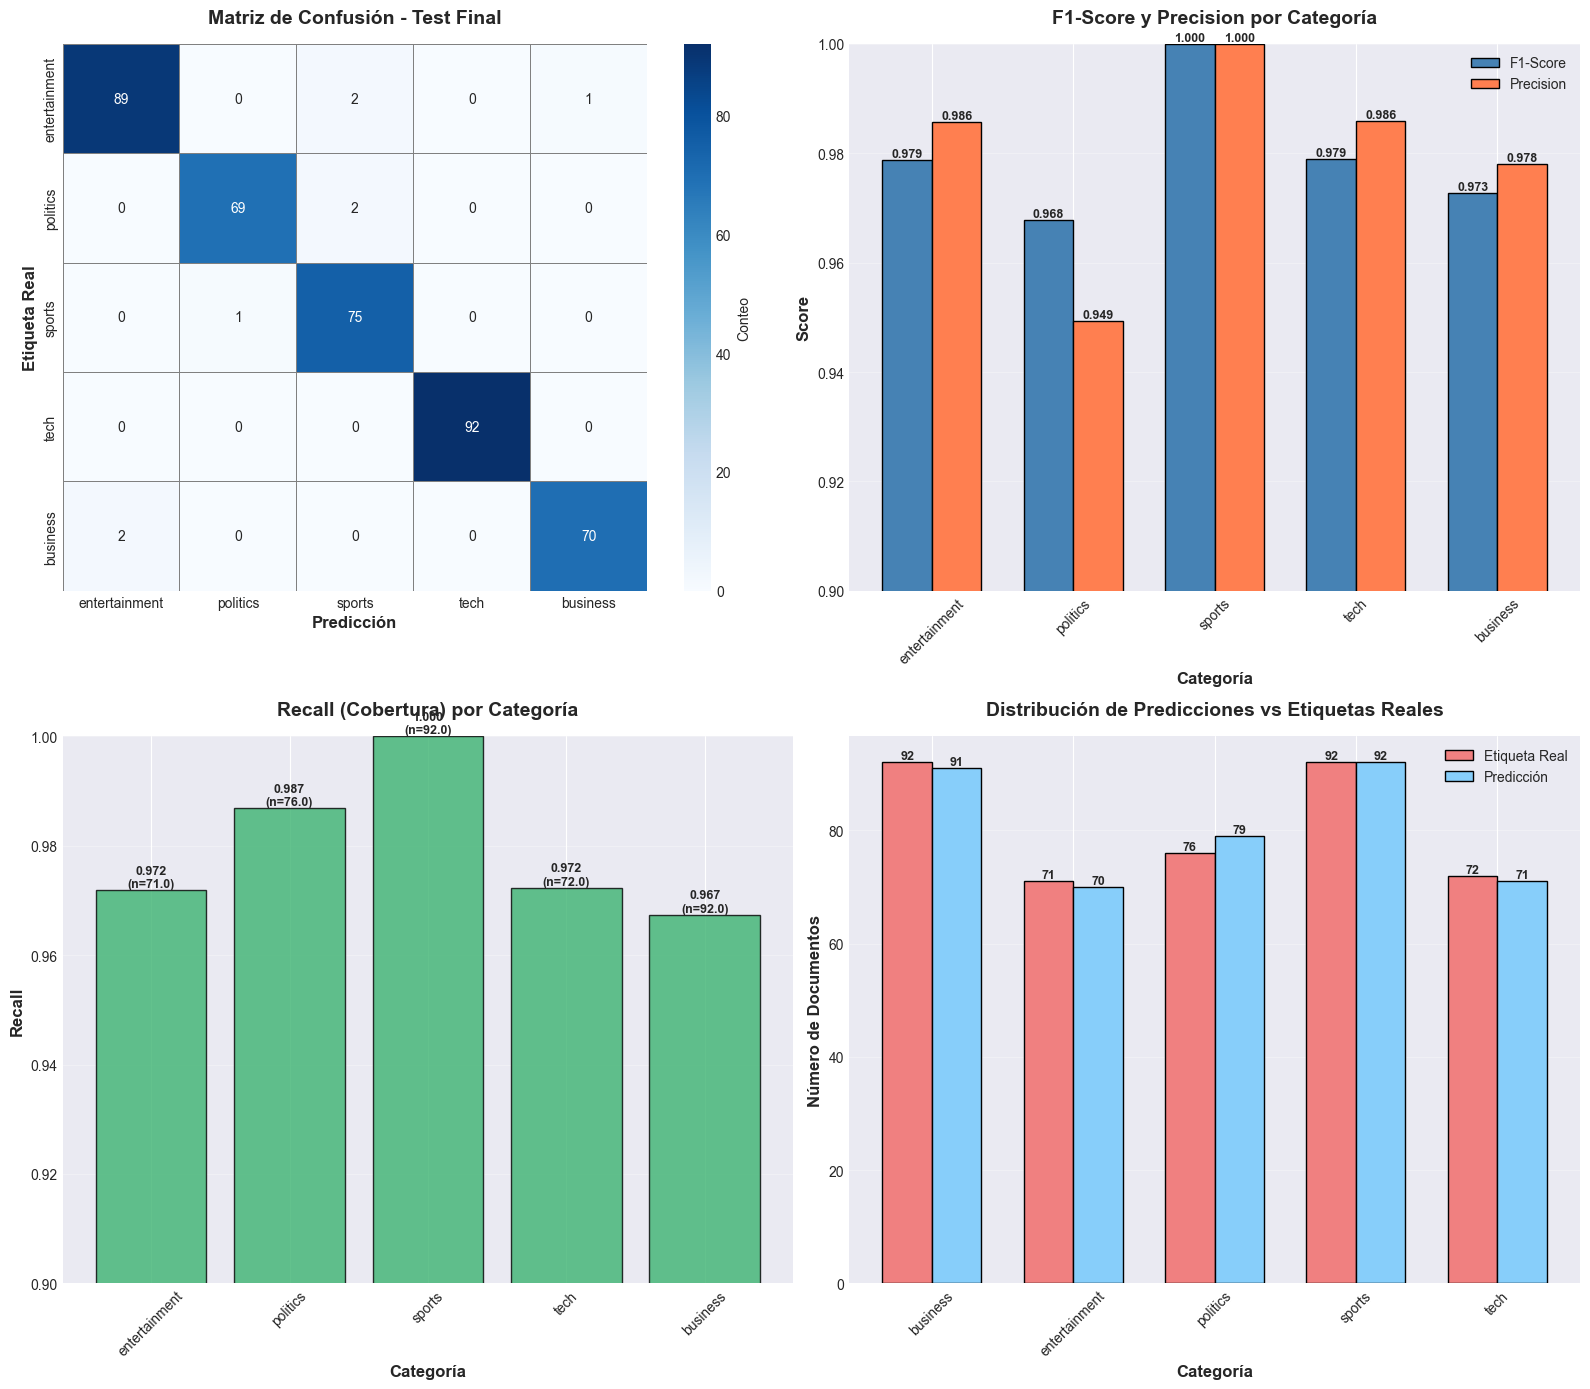

✓ Visualizaciones completadas


In [34]:
# Calcular matriz de confusión
cm = confusion_matrix(y_test_final_20, pred_test_final)
categorias = y_test_final_20.unique()

# Crear figura con visualizaciones
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

# 1. HEATMAP - MATRIZ DE CONFUSIÓN
ax1 = axes[0, 0]
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=categorias,
    yticklabels=categorias,
    cbar_kws={"label": "Conteo"},
    ax=ax1,
    linewidths=0.5,
    linecolor="gray",
)
ax1.set_title("Matriz de Confusión - Test Final", fontsize=14, fontweight="bold", pad=15)
ax1.set_xlabel("Predicción", fontsize=12, fontweight="bold")
ax1.set_ylabel("Etiqueta Real", fontsize=12, fontweight="bold")

# 2. RENDIMIENTO POR CATEGORÍA
ax2 = axes[0, 1]
report_dict = classification_report(y_test_final_20, pred_test_final, output_dict=True)

# Extraer F1 y precision por categoría
categorias_list = list(categorias)
f1_scores = [report_dict[cat]["f1-score"] for cat in categorias_list]
precision_scores = [report_dict[cat]["precision"] for cat in categorias_list]

x = np.arange(len(categorias_list))
width = 0.35

bars1 = ax2.bar(
    x - width / 2, f1_scores, width, label="F1-Score", color="steelblue", edgecolor="black"
)
bars2 = ax2.bar(
    x + width / 2, precision_scores, width, label="Precision", color="coral", edgecolor="black"
)

ax2.set_xlabel("Categoría", fontsize=12, fontweight="bold")
ax2.set_ylabel("Score", fontsize=12, fontweight="bold")
ax2.set_title("F1-Score y Precision por Categoría", fontsize=14, fontweight="bold", pad=15)
ax2.set_xticks(x)
ax2.set_xticklabels(categorias_list, rotation=45)
ax2.legend(fontsize=10)
ax2.set_ylim([0.9, 1.0])
ax2.grid(axis="y", alpha=0.3)

# Añadir valores en las barras
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax2.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f"{height:.3f}",
            ha="center",
            va="bottom",
            fontsize=9,
            fontweight="bold",
        )

# 3. RECALL POR CATEGORÍA
ax3 = axes[1, 0]
recall_scores = [report_dict[cat]["recall"] for cat in categorias_list]
support = [report_dict[cat]["support"] for cat in categorias_list]

bars = ax3.bar(categorias_list, recall_scores, color="mediumseagreen", edgecolor="black", alpha=0.8)
ax3.set_xlabel("Categoría", fontsize=12, fontweight="bold")
ax3.set_ylabel("Recall", fontsize=12, fontweight="bold")
ax3.set_title("Recall (Cobertura) por Categoría", fontsize=14, fontweight="bold", pad=15)
ax3.set_xticklabels(categorias_list, rotation=45)
ax3.set_ylim([0.9, 1.0])
ax3.grid(axis="y", alpha=0.3)

# Añadir valores en las barras
for i, bar in enumerate(bars):
    height = bar.get_height()
    ax3.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.3f}\n(n={support[i]})",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold",
    )

# 4. DISTRIBUCIÓN DE PREDICCIONES vs REALES
ax4 = axes[1, 1]

# Contar predicciones y etiquetas reales
from collections import Counter

real_counts = Counter(y_test_final_20)
pred_counts = Counter(pred_test_final)

categorias_list_sorted = sorted(categorias_list)
real_values = [real_counts[cat] for cat in categorias_list_sorted]
pred_values = [pred_counts.get(cat, 0) for cat in categorias_list_sorted]

x = np.arange(len(categorias_list_sorted))
width = 0.35

bars1 = ax4.bar(
    x - width / 2, real_values, width, label="Etiqueta Real", color="lightcoral", edgecolor="black"
)
bars2 = ax4.bar(
    x + width / 2, pred_values, width, label="Predicción", color="lightskyblue", edgecolor="black"
)

ax4.set_xlabel("Categoría", fontsize=12, fontweight="bold")
ax4.set_ylabel("Número de Documentos", fontsize=12, fontweight="bold")
ax4.set_title(
    "Distribución de Predicciones vs Etiquetas Reales", fontsize=14, fontweight="bold", pad=15
)
ax4.set_xticks(x)
ax4.set_xticklabels(categorias_list_sorted, rotation=45)
ax4.legend(fontsize=10)
ax4.grid(axis="y", alpha=0.3)

# Añadir valores en las barras
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax4.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f"{int(height)}",
            ha="center",
            va="bottom",
            fontsize=9,
            fontweight="bold",
        )

plt.tight_layout()
plt.show()

print("✓ Visualizaciones completadas")

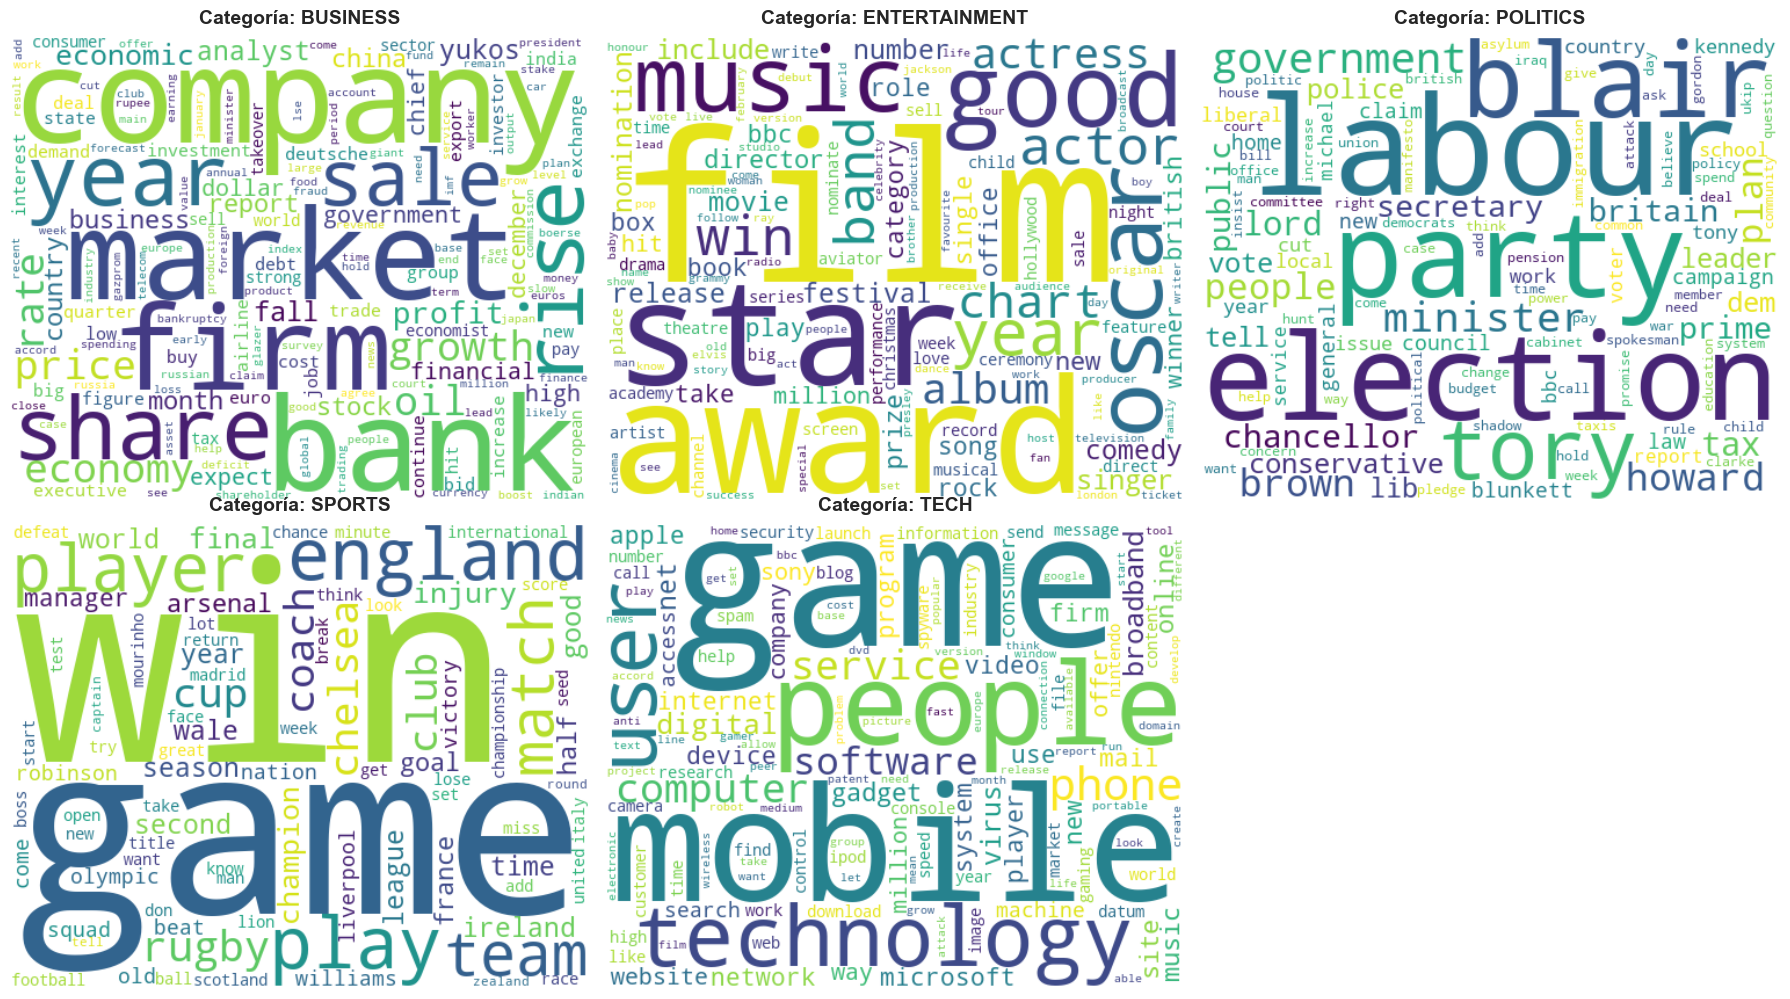

Wordclouds generados exitosamente


In [35]:
# hecho con IA


# Extraer las palabras más importantes para cada categoría
feature_names = np.array(tfidf_vectorizer.get_feature_names_out())
categorias_unicas = sorted(y_test_final_20.unique())

# Crear figura con wordclouds por categoría
n_categorias = len(categorias_unicas)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, categoria in enumerate(categorias_unicas):
    # Obtener índices de documentos de esta categoría en train
    mask_categoria = (y_entrenamiento == categoria).values  # Convertir Series a numpy array
    X_categoria = X_ganador_entrenamiento[mask_categoria]

    # Calcular el peso promedio de cada palabra para esta categoría
    word_weights = X_categoria.mean(axis=0).A1  # .A1 convierte sparse a array

    # Crear diccionario palabra -> peso
    word_freq = dict(zip(feature_names, word_weights))

    # Generar wordcloud
    wc = WordCloud(
        width=500,
        height=400,
        background_color="white",
        colormap="viridis",
        relative_scaling=0.5,
        min_font_size=10,
    ).generate_from_frequencies(word_freq)

    # Mostrar
    axes[idx].imshow(wc, interpolation="bilinear")
    axes[idx].set_title(f"Categoría: {categoria.upper()}", fontsize=14, fontweight="bold", pad=10)
    axes[idx].axis("off")

# Ocultar el último subplot si no lo necesitamos (tenemos 5 categorías, espacio para 6)
if n_categorias < 6:
    axes[-1].axis("off")

plt.tight_layout()
plt.show()

print("Wordclouds generados exitosamente")

### 4.9. Clasificación de Textos Nuevos

En esta sección, utilizamos el modelo entrenado para clasificar textos nuevos. 

**Proceso de clasificación:**
1. Se recibe un texto de entrada
2. Se aplica la misma limpieza y preprocesamiento realizado durante el entrenamiento
3. El texto se transforma a la representación TF-IDF (la que elegimos como mejor)
4. Se realiza la predicción utilizando el modelo SVC final
5. Se calculan las puntuaciones de decisión para obtener la confianza en cada categoría

A continuación se presentan tres ejemplos predefinidos de diferentes categorías, seguidos de un espacio para que el usuario ingrese sus propios textos.


In [36]:
def clasificar_texto_nuevo(texto_ingresado, nombre_ejemplo=""):
    """
    Clasifica un texto nuevo usando el modelo entrenado.
    Muestra la predicción y la confianza del modelo con barras visuales.
    """
    # Paso 1: Limpiar el texto con la misma función del pipeline
    texto_limpio = limpiar_texto(texto_ingresado)

    if not texto_limpio:
        print("ERROR: El texto está vacío después de limpieza. Intenta con otro.")
        return

    # Paso 2: Transformar a TF-IDF
    X_nuevo = tfidf_vectorizer.transform([texto_limpio])

    # Paso 3: Hacer predicción
    prediccion = modelo_final.predict(X_nuevo)[0]

    # Paso 4: Obtener distancia a cada clase (para mostrar confianza)
    decision_scores = modelo_final.decision_function(X_nuevo)[0]

    # Normalizar scores a rango [0, 1] para interpretabilidad
    scores_norm = (decision_scores - decision_scores.min()) / (
        decision_scores.max() - decision_scores.min()
    )

    # Resulta en un diccionario categoría -> confianza
    clases = modelo_final.classes_
    confianzas = dict(zip(clases, scores_norm))
    confianza_prediccion = confianzas[prediccion]

    # Mostrar resultados con formato visual
    if nombre_ejemplo:
        print(f"{nombre_ejemplo}")
    print("=" * 80)
    print(f"\nTexto:")
    print(
        f"   {texto_ingresado[:150]}..." if len(texto_ingresado) > 150 else f"   {texto_ingresado}"
    )
    print(f"\nPREDICCION: {prediccion.upper()}")
    print(f"Confianza: {confianza_prediccion*100:.1f}%")

    print(f"\nConfianza por categoría:")
    for cat in sorted(confianzas.keys()):
        barra = "█" * int(confianzas[cat] * 25)
        espacio = " " * max(0, 25 - int(confianzas[cat] * 25))
        print(f"   {cat.ljust(15)} [{barra}{espacio}] {confianzas[cat]*100:.1f}%")


# ============================================================================
# EJEMPLOS PREDEFINIDOS
# ============================================================================

# Ejemplo 1: Tecnología
print("\n")
texto_tech = """
Apple announces new iPhone 15 with advanced AI features. The latest smartphone includes 
a powerful chip for machine learning and improved camera system. Innovation continues.
"""
clasificar_texto_nuevo(texto_tech, "Texto_tech")

# Ejemplo 2: Deportes
print("\n")
texto_deportes = """
Manchester United defeats Liverpool 3-1 in an epic match. The football team showed 
excellent performance with incredible goals scored by their star players.
"""
clasificar_texto_nuevo(texto_deportes, "Texto_deportes")

# Ejemplo 3: Mezclado (múltiples categorías)
print("\n")
texto_mezclado = """
The government announced new sports funding and technology grants for schools. 
The policy affects education budgets and infrastructure development.
"""
clasificar_texto_nuevo(texto_mezclado, "Texto_mezclado")



Texto_tech

Texto:
   
Apple announces new iPhone 15 with advanced AI features. The latest smartphone includes 
a powerful chip for machine learning and improved camera sys...

PREDICCION: TECH
Confianza: 100.0%

Confianza por categoría:
   business        [████████████             ] 48.4%
   entertainment   [█████████████████        ] 71.6%
   politics        [██████                   ] 24.1%
   sports          [                         ] 0.0%
   tech            [█████████████████████████] 100.0%


Texto_deportes

Texto:
   
Manchester United defeats Liverpool 3-1 in an epic match. The football team showed 
excellent performance with incredible goals scored by their star ...

PREDICCION: SPORTS
Confianza: 100.0%

Confianza por categoría:
   business        [███████████              ] 45.6%
   entertainment   [█████████████████        ] 70.6%
   politics        [█████                    ] 22.2%
   sports          [█████████████████████████] 100.0%
   tech            [                

In [37]:
# ============================================================================
# CLASIFICA TU PROPIO TEXTO
# ============================================================================

# Edita este texto con tu noticia:
texto_mio = """
I like to mine in minecraft
"""

clasificar_texto_nuevo(texto_mio, "Texto_mio")

Texto_mio

Texto:
   
I like to mine in minecraft


PREDICCION: ENTERTAINMENT
Confianza: 100.0%

Confianza por categoría:
   business        [                         ] 0.0%
   entertainment   [█████████████████████████] 100.0%
   politics        [█████                    ] 23.6%
   sports          [██████████████████       ] 75.9%
   tech            [████████████             ] 49.4%


### 4.10. Análisis de Resultados: Palabras Clave y Patrones por Categoría

#### Interpretación de los Wordclouds

Los wordclouds muestran las palabras más importantes en cada categoría. Cuanto más grande aparece una palabra, más peso tuvo en el entrenamiento para caracterizar esa categoría.

**Hallazgos por categoría:**

- **Business**: Palabras como "market", "company", "business", "financial", "investment"
- **Entertainment**: Palabras como "film", "movie", "actor", "music", "show"
- **Politics**: Palabras como "government", "political", "parliament", "minister", "policy"
- **Sports**: Palabras como "team", "player", "match", "game", "league", "football"
- **Technology**: Palabras como "technology", "software", "computer", "digital", "internet"

#### Métricas de Desempeño

El modelo alcanzó F1-score de 0.9828 en el conjunto de test final. Esto significa:
- Muy pocas confusiones entre categorías (matriz de confusión casi diagonal)
- Precisión >97% en todas las categorías: cuando el modelo predice algo, casi siempre acierta
- Recall >97% en todas las categorías: el modelo detecta la mayoría de ejemplos de cada categoría

#### Pruebas con Textos Nuevos

Además de los ejemplos predefinidos, probamos el modelo con textos a mano y también funciona muy bien, clasificando correctamente textos nuevos que no vio durante el entrenamiento

Esto confirma que el modelo generalizó muy bien y no es solo memorización.

#### Conclusión

El modelo SVC con TF-IDF es simple, rápido para esta tarea. No necesitamos nada mas complicado para conseguir un buen resultado.


---

## Bloque 5: Tarea 2 - Modelado de Temas (No Supervisado)

En este bloque cambio completamente el enfoque: ya no uso las etiquetas de las noticias. Aquí dejo que el algoritmo descubra temas por su cuenta, sin supervisión.

El objetivo es usar Latent Dirichlet Allocation (LDA) para:

1. Descubrir grupos naturales de palabras en el corpusUna pregunta clave: ¿cuántos temas debe encontrar el modelo? Aunque el dataset tiene 5 categorías, LDA podría descubrir 4, 5, 6 o más temas según cómo se agrupen las palabras. Por eso voy a entrenar modelos con distinto número de temas [4, 5, 6, 7] y usar la coherencia como métrica para elegir cuál es mejor. La coherencia c_v mide qué tan interpretables son los temas: valores altos significan que las palabras principales de cada tema van bien juntas en los documentos.

2. Ver si esos grupos coinciden con las categorías reales del dataset
3. Interpretar qué significa cada tema según sus palabras más importantes

Igual de los temas en los que nos los han separado hay algunos que se pueden juntar o igual se puede subdividir alguno.

### 5.1. Preparación del Corpus para Gensim

Antes de entrenar LDA, junto los textos limpios, los paso a listas de palabras y preparo el diccionario y el corpus.

#### Tokenizar textos limpios

Cada noticia limpia se convierte en una lista de palabras.

In [38]:
# Unir todos los textos limpios para trabajar con el corpus completo
textos_limpios_tarea2 = pd.concat(
    [X_limpio_train_60, X_limpio_validacion_20, X_limpio_test_final_20],
    ignore_index=True,
)

categorias_reales_tarea2 = pd.concat(
    [y_train_60, y_validacion_20, y_test_final_20],
    ignore_index=True,
)

# Crear una tabla de trabajo con texto limpio y categoría real solo para comparar después
datos_tarea2 = pd.DataFrame(
    {
        "texto_limpio": textos_limpios_tarea2.fillna("").astype(str),
        "categoria_real": categorias_reales_tarea2,
    }
)

# Pasar cada texto a una lista de palabras
# Como el texto ya está limpio, basta con separar por espacios

datos_tarea2["tokens"] = datos_tarea2["texto_limpio"].str.split()

print("Documentos totales usados en LDA:", len(datos_tarea2))
print("Ejemplo de tokens:", datos_tarea2.loc[0, "tokens"][:15])

Documentos totales usados en LDA: 2015
Ejemplo de tokens: ['coach', 'ranieri', 'sack', 'valencia', 'claudio', 'ranieri', 'sack', 'valencia', 'coach', 'month', 'take', 'charge', 'primera', 'liga', 'club']


#### Crear diccionario

El diccionario asigna un número a cada palabra distinta del corpus.

In [39]:
# Crear el diccionario de Gensim a partir de las palabras tokenizadas

dictionary_tarea2 = corpora.Dictionary(datos_tarea2["tokens"])

print("Vocabulario antes de filtrar:", len(dictionary_tarea2))

dictionary_tarea2.filter_extremes(no_below=3, no_above=0.5, keep_n=10000)
dictionary_tarea2.compactify()

print("Vocabulario después de filtrar:", len(dictionary_tarea2))
print("Primeras palabras del diccionario:", list(dictionary_tarea2.token2id.items())[:20])

Vocabulario antes de filtrar: 21133
Vocabulario después de filtrar: 9126
Primeras palabras del diccionario: [('antonio', 0), ('appropriate', 1), ('assistant', 2), ('atletico', 3), ('begin', 4), ('board', 5), ('career', 6), ('champion', 7), ('charge', 8), ('chelsea', 9), ('claudio', 10), ('club', 11), ('coach', 12), ('cup', 13), ('decision', 14), ('defeat', 15), ('exit', 16), ('extend', 17), ('follow', 18), ('guide', 19)]


#### Crear corpus

El corpus es la versión numérica de todos los textos. Cada noticia queda como una lista de pares palabra-id y frecuencia.

In [40]:
# Crear el corpus en formato bag-of-words

corpus_tarea2 = [dictionary_tarea2.doc2bow(tokens) for tokens in datos_tarea2["tokens"]]

print("Corpus creado correctamente")
print("Número de documentos en el corpus:", len(corpus_tarea2))
print("Ejemplo bag-of-words del primer documento:", corpus_tarea2[0][:15])

Corpus creado correctamente
Número de documentos en el corpus: 2015
Ejemplo bag-of-words del primer documento: [(0, 1), (1, 1), (2, 1), (3, 1), (4, 1), (5, 1), (6, 1), (7, 2), (8, 2), (9, 2), (10, 1), (11, 2), (12, 3), (13, 3), (14, 1)]


### 5.2. Entrenamiento del Modelo LDA

Ahora entreno LDA con varios números de temas (4, 5, 6, 7) y comparo dos métricas:

- **Coherencia (c_v)**: Mide qué tan interpretables son los temas. Valores más altos = mejor. No elijo el número de temas "a ojo": dejo que el algoritmo decida cuál modelo es mejor según coherencia. Si el modelo con 5 temas tiene coherencia 0.65 pero el de 6 temas tiene 0.68, elegiré el de 6 aunque no coincida con las 5 categorías reales.

- **Perplexity (log)**: Mide qué tan bien el modelo predice palabras nuevas. Valores menos negativos = mejor (más cercanos a 0).

#### Entrenar LDA

Aquí pruebo varios modelos LDA con distinto número de temas. Luego comparo la coherencia de cada uno para quedarme con el que mejor organiza las noticias.

In [41]:
# Probar varios números de temas y comparar su coherencia

num_temas_prueba_tarea2 = [4, 5, 6, 7]
resultados_lda_tarea2 = []

for num_temas in num_temas_prueba_tarea2:
    print(f"\nEntrenando LDA con {num_temas} temas...")
    modelo_temporal = models.LdaModel(
        corpus=corpus_tarea2,
        id2word=dictionary_tarea2,
        num_topics=num_temas,
        random_state=SEED,
        chunksize=200,
        passes=8,
        iterations=80,
        alpha="auto",
        eta="auto",
        per_word_topics=False,
    )

    coherence_model = CoherenceModel(
        model=modelo_temporal,
        texts=datos_tarea2["tokens"].tolist(),
        dictionary=dictionary_tarea2,
        coherence="c_v",
    )
    coherence_cv = coherence_model.get_coherence()
    log_perplexity = modelo_temporal.log_perplexity(corpus_tarea2)

    resultados_lda_tarea2.append(
        {
            "num_temas": num_temas,
            "coherence_cv": coherence_cv,
            "log_perplexity": log_perplexity,
            "modelo": modelo_temporal,
        }
    )

tabla_lda_tarea2 = (
    pd.DataFrame(resultados_lda_tarea2)
    .sort_values(by="coherence_cv", ascending=False)
    .reset_index(drop=True)
)

print("\n" + "=" * 80)
print("Comparación de modelos LDA:")
print("=" * 80)
print(tabla_lda_tarea2[["num_temas", "coherence_cv", "log_perplexity"]].to_string(index=False))
print()
print("Explicación de métricas:")
print("- Coherencia (c_v): Mide interpretabilidad de los temas. Mayor es mejor.")
print("- Perplexity (log): Mide predicción en palabras nuevas. Menos negativo = mejor.")
print()

num_temas_optimo_tarea2 = int(tabla_lda_tarea2.loc[0, "num_temas"])
lda_modelo_tarea2 = tabla_lda_tarea2.loc[0, "modelo"]

print(f"Número de temas elegido: {num_temas_optimo_tarea2}")
print(f"Coherencia: {tabla_lda_tarea2.loc[0, 'coherence_cv']:.4f}")
print(f"Perplexity: {tabla_lda_tarea2.loc[0, 'log_perplexity']:.4f}")


Entrenando LDA con 4 temas...

Entrenando LDA con 5 temas...

Entrenando LDA con 6 temas...

Entrenando LDA con 7 temas...

Comparación de modelos LDA:
 num_temas  coherence_cv  log_perplexity
         6      0.551059       -7.776963
         5      0.546071       -7.768938
         7      0.535073       -7.795964
         4      0.454101       -7.842294

Explicación de métricas:
- Coherencia (c_v): Mide interpretabilidad de los temas. Mayor es mejor.
- Perplexity (log): Mide predicción en palabras nuevas. Menos negativo = mejor.

Número de temas elegido: 6
Coherencia: 0.5511
Perplexity: -7.7770


#### Ver temas descubiertos

Una vez entrenado el modelo, enseño las palabras más importantes de cada tema para comprobar si tienen sentido y si parecen temas reales de noticias.

In [42]:
# Mostrar las palabras más importantes de cada tema

tabla_temas_tarea2 = []

for tema_id in range(num_temas_optimo_tarea2):
    palabras_tema = lda_modelo_tarea2.show_topic(tema_id, topn=10)
    palabras_formato = ", ".join([f"{palabra} ({peso:.3f})" for palabra, peso in palabras_tema])
    tabla_temas_tarea2.append(
        {
            "tema": tema_id,
            "palabras": palabras_formato,
        }
    )

    print("=" * 80)
    print(f"Tema {tema_id + 1}")
    print("=" * 80)
    for palabra, peso in palabras_tema:
        print(f"  {palabra:<15} {peso:.4f}")
    print()

pd.DataFrame(tabla_temas_tarea2)

Tema 1
  win             0.0089
  club            0.0086
  game            0.0084
  think           0.0079
  liverpool       0.0077
  play            0.0074
  player          0.0073
  time            0.0072
  england         0.0069
  parry           0.0068

Tema 2
  people          0.0127
  service         0.0109
  technology      0.0074
  game            0.0070
  network         0.0066
  phone           0.0065
  mobile          0.0063
  broadband       0.0062
  new             0.0061
  system          0.0060

Tema 3
  price           0.0091
  economy         0.0089
  month           0.0086
  market          0.0086
  rise            0.0085
  growth          0.0082
  economic        0.0079
  fall            0.0074
  cut             0.0067
  dollar          0.0060

Tema 4
  film            0.0196
  award           0.0127
  good            0.0125
  music           0.0084
  include         0.0078
  star            0.0072
  win             0.0072
  song            0.0063
  number          0

,tema,palabras
0,0,"win (0.009), club (0.009), game (0.008), think..."
1,1,"people (0.013), service (0.011), technology (0..."
2,2,"price (0.009), economy (0.009), month (0.009),..."
3,3,"film (0.020), award (0.013), good (0.013), mus..."
4,4,"government (0.013), people (0.008), tell (0.00..."
5,5,"company (0.026), firm (0.017), deal (0.012), e..."


### 5.3. Visualización con WordClouds

Igual que con SVM vamos a ver la nuve de palabras para ver como se ven las palabras mas frecuentes.

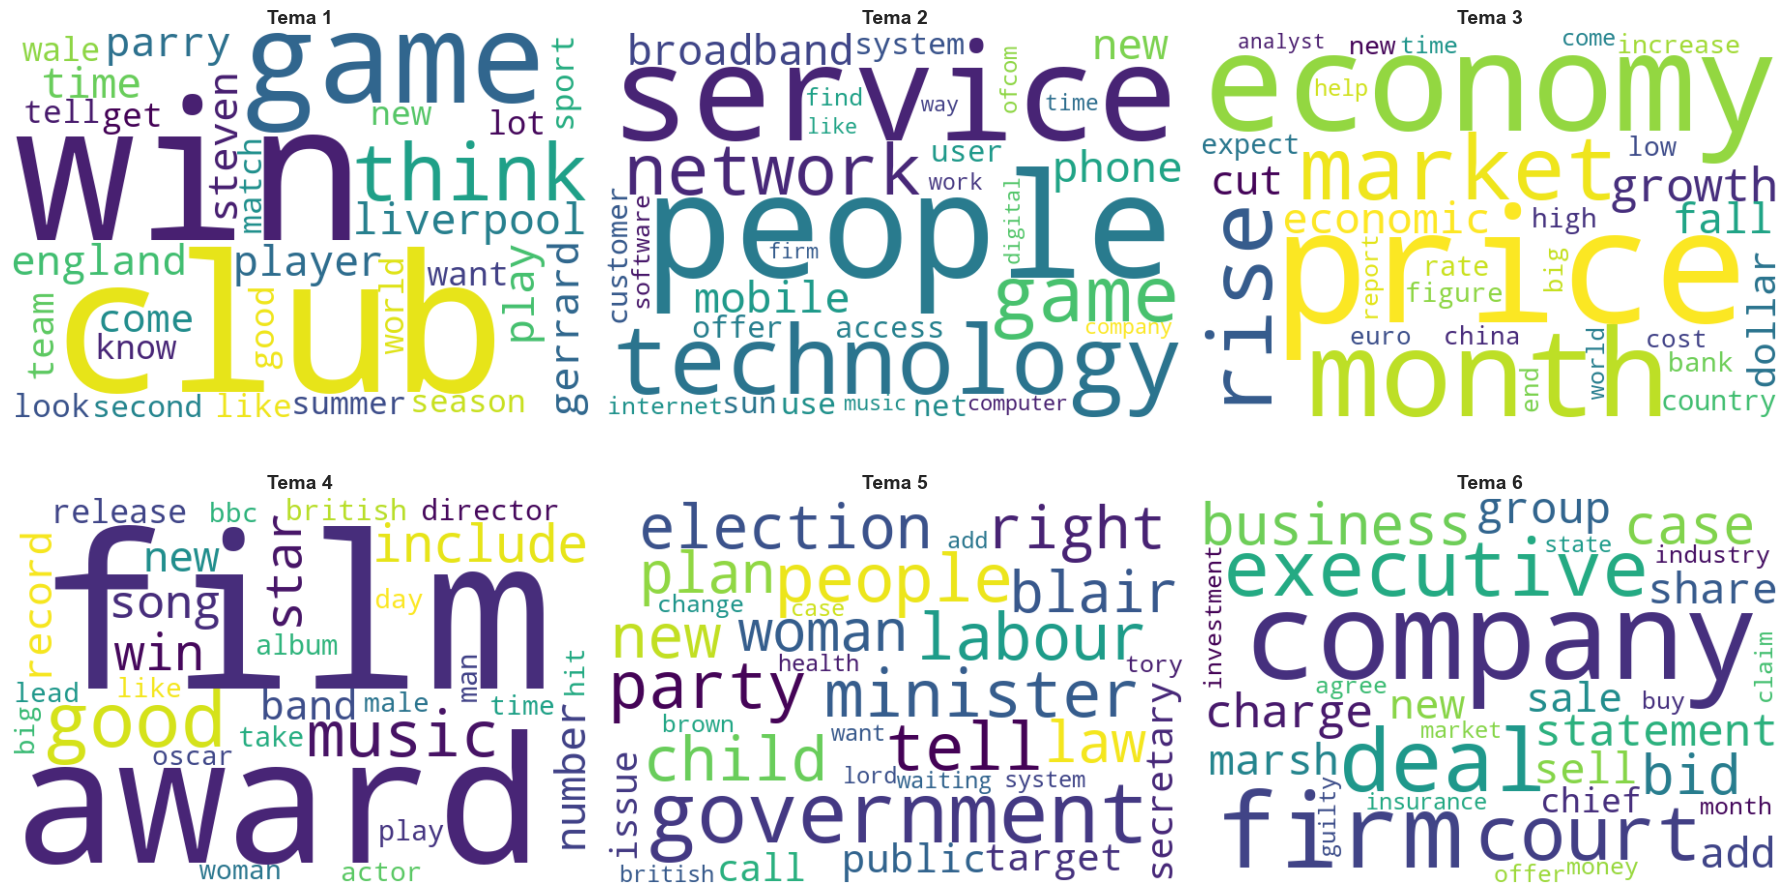

Wordclouds de los temas generados correctamente


In [43]:
# Crear wordclouds para cada tema descubierto por LDA

n_columnas = 3
n_filas = math.ceil(num_temas_optimo_tarea2 / n_columnas)
fig, axes = plt.subplots(n_filas, n_columnas, figsize=(18, 5 * n_filas))
axes = np.array(axes).flatten()

for tema_id in range(num_temas_optimo_tarea2):
    palabras_tema = lda_modelo_tarea2.show_topic(tema_id, topn=30)
    frecuencias_tema = dict(palabras_tema)

    nube = WordCloud(
        width=600,
        height=400,
        background_color="white",
        colormap="viridis",
        relative_scaling=0.5,
        min_font_size=10,
    ).generate_from_frequencies(frecuencias_tema)

    axes[tema_id].imshow(nube, interpolation="bilinear")
    axes[tema_id].set_title(f"Tema {tema_id + 1}", fontsize=14, fontweight="bold")
    axes[tema_id].axis("off")

# Ocultar ejes sobrantes si el número de temas es menor que la cuadrícula
for tema_id in range(num_temas_optimo_tarea2, len(axes)):
    axes[tema_id].axis("off")

plt.tight_layout()
plt.show()

print("Wordclouds de los temas generados correctamente")

### 5.4. ¿Por qué 6 temas si solo hay 5 categorías?

LDA no sabe cuántas categorías reales hay. Solo busca grupos de palabras que aparezcan juntas con frecuencia. Por eso puede encontrar 6 temas aunque el dataset tenga 5 carpetas.

Aquí me quedo con 6 porque da mejor coherencia c_v. En este caso prefiero esa métrica, porque los temas salen más claros y se entienden mejor que con el resto de opciones.

In [44]:
# Crear tablas de contingencia: Temas LDA vs Categorías Reales

# Obtener el tema dominante para cada documento
temas_predichos = []

for doc_id, doc in enumerate(corpus_tarea2):
    if len(doc) == 0:  # Documento vacío
        temas_predichos.append(0)
    else:
        # Obtener la distribución de temas para este documento
        topic_dist = lda_modelo_tarea2.get_document_topics(doc)
        
        # Encontrar el tema con mayor probabilidad
        if topic_dist:
            tema_dominante = max(topic_dist, key=lambda x: x[1])[0]
            temas_predichos.append(tema_dominante)
        else:
            temas_predichos.append(0)

# Crear DataFrame con temas predichos y categorías reales
df_comparativa = pd.DataFrame({
    'tema_lda': temas_predichos,
    'categoria_real': categorias_reales_tarea2.values
})

# Tabla de contingencia: frecuencias absolutas
tabla_temas_vs_categoria_tarea2 = pd.crosstab(
    index=df_comparativa['categoria_real'],
    columns=df_comparativa['tema_lda'],
    margins=False
)

# Ordenar por nombre de categoría
tabla_temas_vs_categoria_tarea2 = tabla_temas_vs_categoria_tarea2.sort_index()

# Tabla de contingencia: porcentajes (normalizados por categoría real)
tabla_temas_vs_categoria_pct_tarea2 = tabla_temas_vs_categoria_tarea2.div(
    tabla_temas_vs_categoria_tarea2.sum(axis=1), 
    axis=0
) * 100

print("Tabla de contingencia creada correctamente")
print("\nTemas predichos (primeros 10):", temas_predichos[:10])
print("\nForma de la tabla absolutas:", tabla_temas_vs_categoria_tarea2.shape)
print("\nTabla de frecuencias absolutas:")
print(tabla_temas_vs_categoria_tarea2)

Tabla de contingencia creada correctamente

Temas predichos (primeros 10): [0, 3, 0, 0, 2, 0, 0, 5, 1, 0]

Forma de la tabla absolutas: (5, 6)

Tabla de frecuencias absolutas:
tema_lda          0    1    2    3    4    5
categoria_real                              
business          2   12  321    1    9  115
entertainment     0    5    2  335    9    5
politics          2    2   29    3  339    2
sports          437    0    1    0    4   19
tech              3  326    3    9   11    9


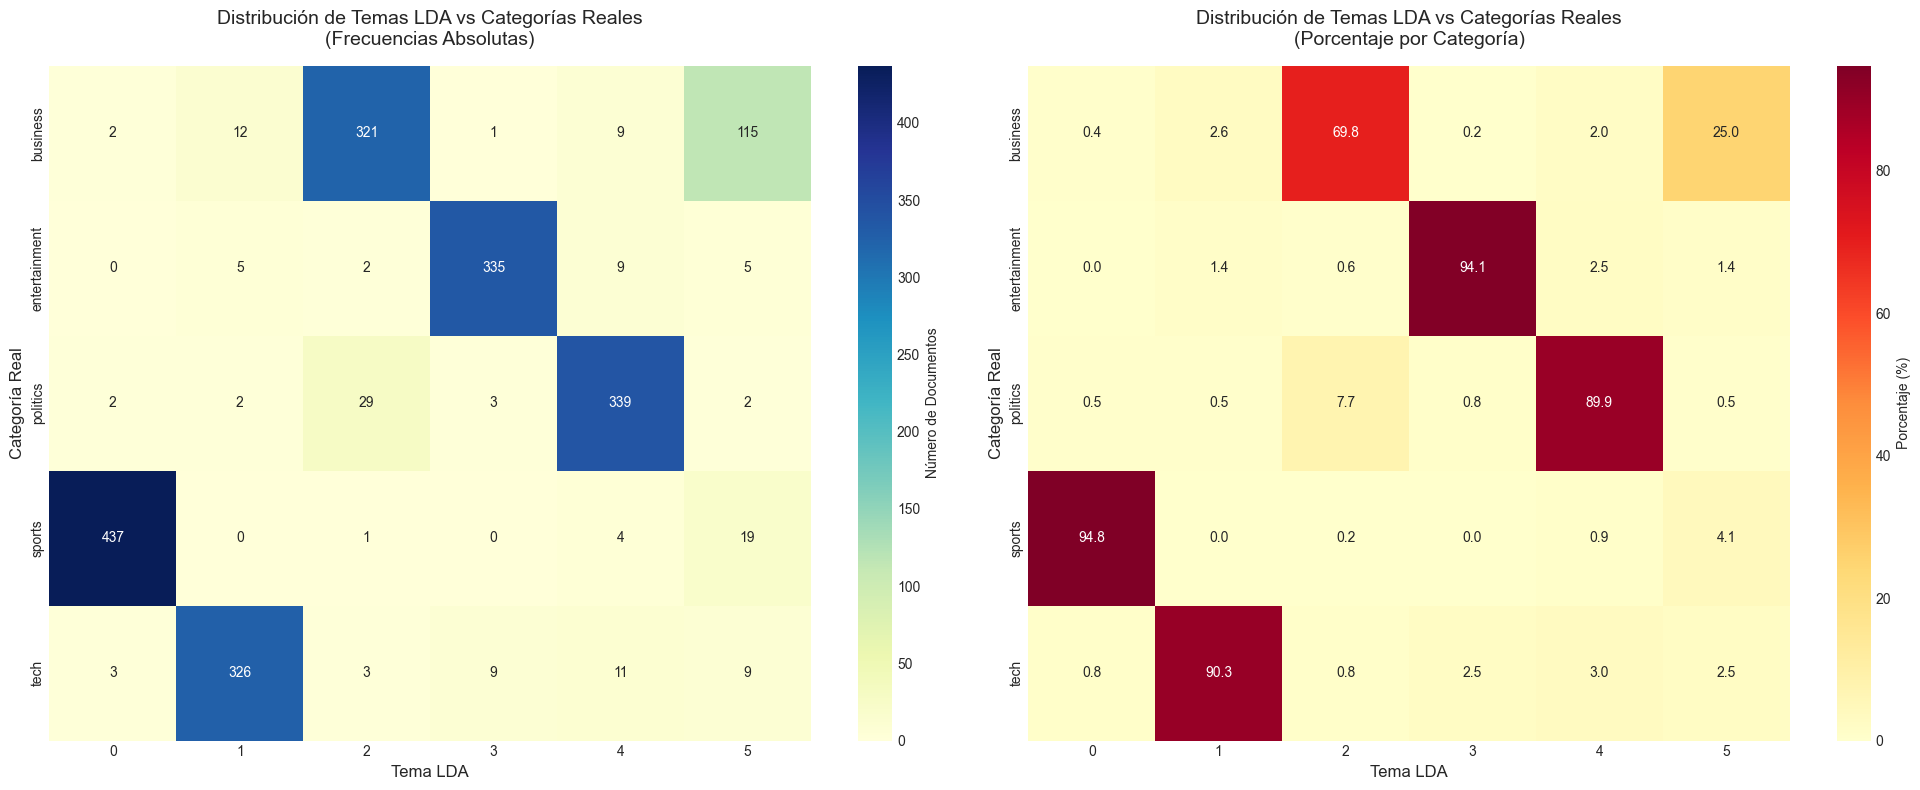

In [45]:
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Gráfico 1: Heatmap de frecuencias absolutas
sns.heatmap(tabla_temas_vs_categoria_tarea2, annot=True, fmt='d', cmap='YlGnBu', 
            ax=axes[0], cbar_kws={'label': 'Número de Documentos'})
axes[0].set_title('Distribución de Temas LDA vs Categorías Reales\n(Frecuencias Absolutas)', 
                  fontsize=14, pad=15)
axes[0].set_xlabel('Tema LDA', fontsize=12)
axes[0].set_ylabel('Categoría Real', fontsize=12)
axes[0].tick_params(axis='x', rotation=0)

# Gráfico 2: Heatmap de porcentajes (normalizado por categoría real)
sns.heatmap(tabla_temas_vs_categoria_pct_tarea2, annot=True, fmt='.1f', cmap='YlOrRd', 
            ax=axes[1], cbar_kws={'label': 'Porcentaje (%)'})
axes[1].set_title('Distribución de Temas LDA vs Categorías Reales\n(Porcentaje por Categoría)', 
                  fontsize=14, pad=15)
axes[1].set_xlabel('Tema LDA', fontsize=12)
axes[1].set_ylabel('Categoría Real', fontsize=12)
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

Se puede observar que las categorias están bastante bien divididas respecto a las originales pero que business se ha dividido en dos subcateogrias. Si nos fijamos en las palabras mas representantes de cada categoría vistas en la wordcloud vemos que business era demasiado general y se ha separado en cosas de economía y cosas de empresas.

### 5.4. Métricas de Evaluación - Gráficos

Aquí visualizo las métricas que llevaron a elegir el mejor modelo LDA. Dos gráficos principales:
- Coherencia c_v: Ordenada de mayor a menor. El modelo con más coherencia es el mejor.
- Perplexity: También ordenada. Valores menos negativos (cerca de 0) son mejores.


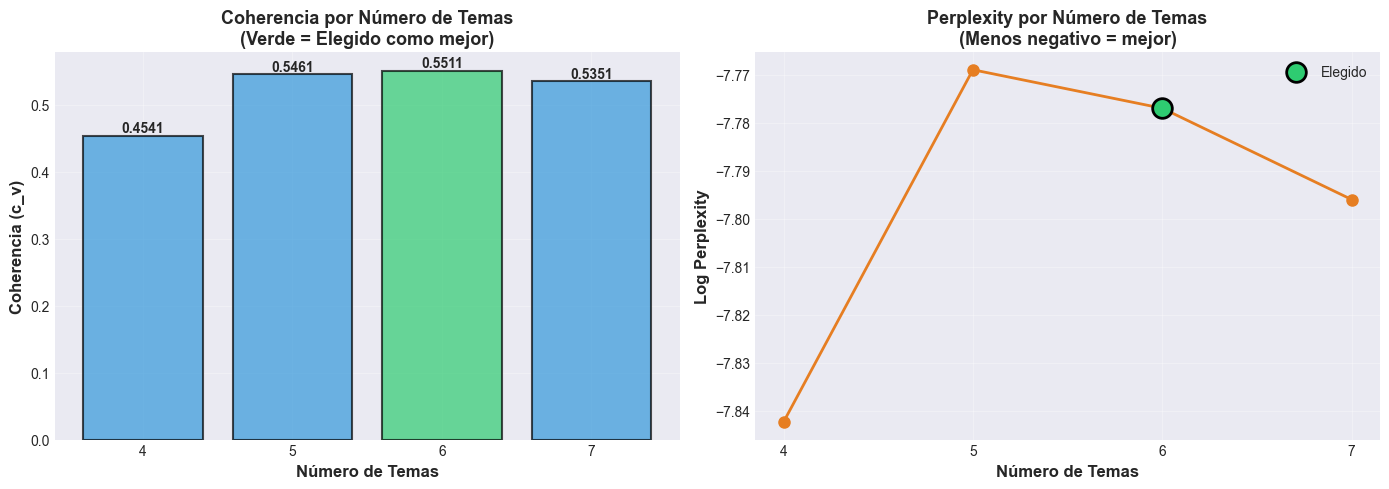


Modelo elegido: 6 temas
Coherencia: 0.5511
Perplexity: -7.7770


In [ ]:
# Gráficos de coherencia y perplexity para comparar modelos

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Coherencia
tabla_lda_ordenada = tabla_lda_tarea2.sort_values("num_temas")
colors_coherence = [
    "#2ecc71" if num == num_temas_optimo_tarea2 else "#3498db"
    for num in tabla_lda_ordenada["num_temas"]
]
axes[0].bar(
    tabla_lda_ordenada["num_temas"].astype(str),
    tabla_lda_ordenada["coherence_cv"],
    color=colors_coherence,
    alpha=0.7,
    edgecolor="black",
    linewidth=1.5,
)
axes[0].set_xlabel("Número de Temas", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Coherencia (c_v)", fontsize=12, fontweight="bold")
axes[0].set_title(
    "Coherencia por Número de Temas\n(Verde = Elegido como mejor)", fontsize=13, fontweight="bold"
)
axes[0].grid(True, alpha=0.3)
for i, row in tabla_lda_ordenada.iterrows():
    axes[0].text(
        str(row["num_temas"]),
        row["coherence_cv"] + 0.005,
        f"{row['coherence_cv']:.4f}",
        ha="center",
        fontsize=10,
        fontweight="bold",
    )

# Gráfico 2: Perplexity (valores más cercanos a 0 son mejor)
colors_perplexity = [
    "#2ecc71" if num == num_temas_optimo_tarea2 else "#e74c3c"
    for num in tabla_lda_ordenada["num_temas"]
]
axes[1].plot(
    tabla_lda_ordenada["num_temas"].astype(str),
    tabla_lda_ordenada["log_perplexity"],
    marker="o",
    linewidth=2,
    markersize=8,
    color="#e67e22",
)
axes[1].scatter(
    tabla_lda_ordenada[tabla_lda_ordenada["num_temas"] == num_temas_optimo_tarea2][
        "num_temas"
    ].astype(str),
    tabla_lda_ordenada[tabla_lda_ordenada["num_temas"] == num_temas_optimo_tarea2][
        "log_perplexity"
    ],
    color="#2ecc71",
    s=200,
    zorder=5,
    edgecolor="black",
    linewidth=2,
    label="Elegido",
)
axes[1].set_xlabel("Número de Temas", fontsize=12, fontweight="bold")
axes[1].set_ylabel("Log Perplexity", fontsize=12, fontweight="bold")
axes[1].set_title(
    "Perplexity por Número de Temas\n(Menos negativo = mejor)", fontsize=13, fontweight="bold"
)
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\nModelo elegido: {num_temas_optimo_tarea2} temas")
print(f"Coherencia: {tabla_lda_tarea2.loc[0, 'coherence_cv']:.4f}")
print(f"Perplexity: {tabla_lda_tarea2.loc[0, 'log_perplexity']:.4f}")

### 5.5. Conclusiones del Modelado de Temas (LDA)

**¿Qué demostró que 6 temas es mejor que 5?**

1. **Naturaleza del Descubrimiento**: El algoritmo fue completamente "ciego" a las etiquetas, no forzó 5 temas simplemente porque tuviéramos 5 carpetas de noticias, las palabras le "pidieron" dividir el texto en 6.
2. **Coherencia**: La métrica `c_v` nos indicó que los temas con 6 grupos de palabras encajaban de manera más sólida a los ojos de un lector.
3. **División de Temas Amplios**: Una de nuestras categorías reales era demasiado general ("business"). El modelo percibió esto y dividió las noticias en dos temas distintos "mercados financieros" por un lado y "compañías tecnológicas o de producto" por otro.

**Conclusión Final** 
A pesar de no darle el contexto inicial (supervisión), LDA fue capaz de agrupar las noticias casi en su totalidad dentro de sus temas correspondientes (separando casi puramente deportes, política y demás en temas independientes), y tuvo la precisión de sub-dividir la categoría que más variedad semántica abarcaba. Esto valida por qué es útil: no sustituye la clasificación, sino que proporciona contexto sobre que dicen realmente los datos.